[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/YOUR-USERNAME/AI-in-healthcare-book/blob/main/notebooks/chapter_09/notebook_9_3_bias_mitigation.ipynb)

*Click the badge above to open this notebook in Google Colab (no setup required)*

---


# Notebook 9.3: Bias Mitigation Strategies

**Chapter 9: Fairness and Bias in Healthcare AI**

In this notebook, we implement and compare three major approaches to bias mitigation:

1. **Pre-processing**: Modify training data before model training
2. **In-processing**: Incorporate fairness constraints during training
3. **Post-processing**: Adjust model predictions after training

We'll apply these techniques to a realistic healthcare scenario: melanoma detection across different skin tones.

## Learning Objectives

By the end of this notebook, you will:
- Understand the three main categories of bias mitigation
- Implement resampling and SMOTE for data balancing
- Train fairness-constrained models with custom loss functions
- Apply threshold optimization for post-processing fairness
- Compare mitigation strategies on clinical metrics
- Understand fairness-accuracy trade-offs

## Clinical Context

**Problem**: Melanoma detection models trained on predominantly light-skinned patients achieve:
- Sensitivity: 92% on light skin, 68% on dark skin
- This 24 percentage point gap means dark-skinned patients face significantly higher rates of missed melanomas

**Goal**: Apply bias mitigation to improve sensitivity on dark skin while maintaining overall clinical utility.

---

## Part 1: Setup and Baseline Model

First, let's create a realistic biased dataset and establish baseline performance.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.utils import resample
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print("✓ Libraries imported successfully")
print("\nPackages used:")
print("- NumPy, Pandas: Data manipulation")
print("- Scikit-learn: Machine learning models")
print("- imbalanced-learn: SMOTE implementation")
print("- Matplotlib, Seaborn: Visualization")

✓ Libraries imported successfully

Packages used:
- NumPy, Pandas: Data manipulation
- Scikit-learn: Machine learning models
- imbalanced-learn: SMOTE implementation
- Matplotlib, Seaborn: Visualization


### Create Realistic Biased Dataset

We'll create a melanoma detection dataset with:
- **Representation bias**: 85% light skin, 15% dark skin (reflects many dermatology datasets)
- **Label quality bias**: Dark skin images have lower-quality annotations
- **Feature measurement bias**: Some features (e.g., redness) are harder to measure on dark skin

In [2]:
def create_melanoma_dataset(n_samples=5000):
    """
    Create synthetic melanoma detection dataset with realistic bias.

    Features (simulating dermatoscopy measurements):
    - asymmetry: 0-1 (lesion asymmetry)
    - border_irregularity: 0-1
    - color_variation: 0-1
    - diameter: mm
    - redness: 0-1 (harder to measure on dark skin)
    - pigment_network: 0-1

    Protected attribute:
    - skin_tone: 'light' or 'dark'

    Label:
    - malignant: 0 (benign) or 1 (melanoma)
    """
    # Representation bias: 85% light, 15% dark
    n_light = int(n_samples * 0.85)
    n_dark = n_samples - n_light

    skin_tone = ['light'] * n_light + ['dark'] * n_dark

    # True melanoma prevalence (similar across groups)
    melanoma_rate = 0.15

    data = []

    for i, tone in enumerate(skin_tone):
        # Ground truth: is this actually melanoma?
        is_melanoma = np.random.random() < melanoma_rate

        if is_melanoma:
            # Melanoma features (more extreme values)
            asymmetry = np.random.beta(8, 2)  # Skewed toward 1
            border_irregularity = np.random.beta(7, 2)
            color_variation = np.random.beta(7, 3)
            diameter = np.random.normal(8, 2)  # Larger
            redness = np.random.beta(6, 3)
            pigment_network = np.random.beta(3, 7)  # Atypical
        else:
            # Benign features (more normal values)
            asymmetry = np.random.beta(2, 8)  # Skewed toward 0
            border_irregularity = np.random.beta(2, 7)
            color_variation = np.random.beta(3, 7)
            diameter = np.random.normal(4, 1.5)  # Smaller
            redness = np.random.beta(3, 6)
            pigment_network = np.random.beta(7, 3)  # Typical

        # Measurement bias: redness harder to measure on dark skin
        if tone == 'dark':
            # Add noise to redness measurement
            redness += np.random.normal(0, 0.15)
            redness = np.clip(redness, 0, 1)

        # Label quality bias: dark skin has noisier labels
        if tone == 'dark':
            # 10% chance of label error
            if np.random.random() < 0.10:
                is_melanoma = not is_melanoma
        else:
            # 3% chance of label error
            if np.random.random() < 0.03:
                is_melanoma = not is_melanoma

        data.append({
            'asymmetry': asymmetry,
            'border_irregularity': border_irregularity,
            'color_variation': color_variation,
            'diameter': diameter,
            'redness': redness,
            'pigment_network': pigment_network,
            'skin_tone': tone,
            'malignant': int(is_melanoma)
        })

    df = pd.DataFrame(data)

    # Clip all features to valid ranges
    for col in ['asymmetry', 'border_irregularity', 'color_variation', 'redness', 'pigment_network']:
        df[col] = df[col].clip(0, 1)
    df['diameter'] = df['diameter'].clip(1, 20)

    return df

# Create dataset
df = create_melanoma_dataset(n_samples=5000)

print("Dataset created successfully!")
print(f"\nTotal samples: {len(df)}")
print(f"\nSkin tone distribution:")
print(df['skin_tone'].value_counts())
print(f"\nMelanoma prevalence:")
print(df.groupby('skin_tone')['malignant'].agg(['sum', 'mean']))
print("\nFirst few rows:")
df.head()

Dataset created successfully!

Total samples: 5000

Skin tone distribution:
skin_tone
light    4250
dark      750
Name: count, dtype: int64

Melanoma prevalence:
           sum      mean
skin_tone               
dark       150  0.200000
light      695  0.163529

First few rows:


,asymmetry,border_irregularity,color_variation,diameter,redness,pigment_network,skin_tone,malignant
0,0.065727,0.175745,0.252693,1.000000,0.558969,0.562277,light,0
1,0.221183,0.296003,0.250636,2.413434,0.257896,0.765249,light,0
2,0.159230,0.167168,0.179677,4.873184,0.530185,0.750798,light,0
3,0.161473,0.303248,0.757906,5.232854,0.100803,0.857431,light,0
4,0.174742,0.367289,0.282568,1.000000,0.400886,0.403991,light,0


### Visualize Dataset Characteristics

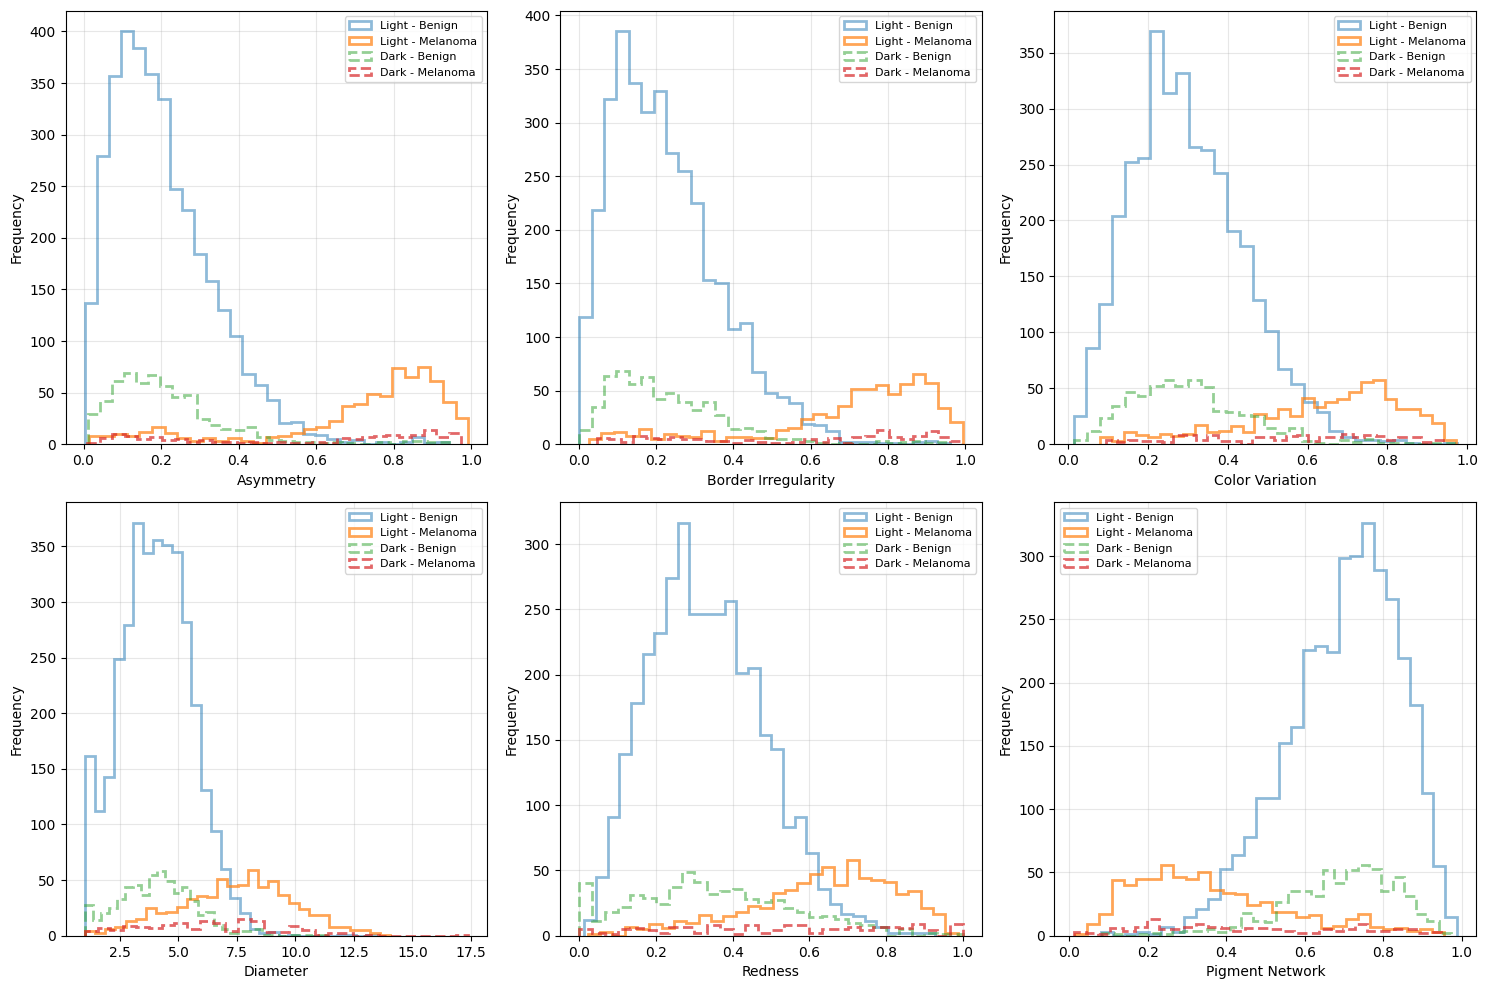


Key observations:
1. Malignant lesions have higher asymmetry, border irregularity, and color variation
2. Redness measurement is noisier for dark skin (visible as wider distribution)
3. These biases will affect model performance differently across groups


In [3]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

features = ['asymmetry', 'border_irregularity', 'color_variation',
            'diameter', 'redness', 'pigment_network']

for idx, feature in enumerate(features):
    ax = axes[idx // 3, idx % 3]

    # Plot distributions by skin tone and malignancy
    for tone in ['light', 'dark']:
        for malignant in [0, 1]:
            subset = df[(df['skin_tone'] == tone) & (df['malignant'] == malignant)]
            label = f"{tone.capitalize()} - {'Melanoma' if malignant else 'Benign'}"
            alpha = 0.5 if malignant == 0 else 0.7
            linestyle = '-' if tone == 'light' else '--'
            ax.hist(subset[feature], bins=30, alpha=alpha,
                   label=label, linestyle=linestyle, histtype='step', linewidth=2)

    ax.set_xlabel(feature.replace('_', ' ').title())
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('dataset_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey observations:")
print("1. Malignant lesions have higher asymmetry, border irregularity, and color variation")
print("2. Redness measurement is noisier for dark skin (visible as wider distribution)")
print("3. These biases will affect model performance differently across groups")

### Train Baseline Model (No Mitigation)

Let's establish baseline performance to understand the bias problem.

In [4]:
# Prepare features and labels
feature_cols = ['asymmetry', 'border_irregularity', 'color_variation',
                'diameter', 'redness', 'pigment_network']

X = df[feature_cols].values
y = df['malignant'].values
groups = df['skin_tone'].values

# Split into train/test (stratified by both label and group)
X_train, X_test, y_train, y_test, groups_train, groups_test = train_test_split(
    X, y, groups, test_size=0.3, random_state=42, stratify=y
)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"\nTraining set skin tone distribution:")
print(pd.Series(groups_train).value_counts())
print(f"\nTest set skin tone distribution:")
print(pd.Series(groups_test).value_counts())

Training samples: 3500
Test samples: 1500

Training set skin tone distribution:
light    2959
dark      541
Name: count, dtype: int64

Test set skin tone distribution:
light    1291
dark      209
Name: count, dtype: int64


In [5]:
# Train baseline model
baseline_model = LogisticRegression(random_state=42, max_iter=1000)
baseline_model.fit(X_train, y_train)

# Predictions
y_pred_baseline = baseline_model.predict(X_test)
y_prob_baseline = baseline_model.predict_proba(X_test)[:, 1]

print("✓ Baseline model trained")
print(f"\nOverall Test Accuracy: {(y_pred_baseline == y_test).mean():.3f}")
print(f"Overall Test AUC: {roc_auc_score(y_test, y_prob_baseline):.3f}")

✓ Baseline model trained

Overall Test Accuracy: 0.963
Overall Test AUC: 0.896


### Evaluate Baseline by Subgroup

The key question: does performance differ between light and dark skin?

In [6]:
def evaluate_fairness(y_true, y_pred, y_prob, groups, model_name="Model"):
    """
    Comprehensive fairness evaluation across subgroups.
    """
    results = {}

    for group in np.unique(groups):
        mask = groups == group
        y_true_group = y_true[mask]
        y_pred_group = y_pred[mask]
        y_prob_group = y_prob[mask]

        # Confusion matrix
        tn, fp, fn, tp = confusion_matrix(y_true_group, y_pred_group).ravel()

        # Clinical metrics
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # Recall
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        ppv = tp / (tp + fp) if (tp + fp) > 0 else 0  # Precision
        npv = tn / (tn + fn) if (tn + fn) > 0 else 0
        accuracy = (tp + tn) / (tp + tn + fp + fn)

        # AUC
        auc = roc_auc_score(y_true_group, y_prob_group) if len(np.unique(y_true_group)) > 1 else np.nan

        # Selection rate (positive prediction rate)
        selection_rate = y_pred_group.mean()

        results[group] = {
            'n': len(y_true_group),
            'prevalence': y_true_group.mean(),
            'sensitivity': sensitivity,
            'specificity': specificity,
            'ppv': ppv,
            'npv': npv,
            'accuracy': accuracy,
            'auc': auc,
            'selection_rate': selection_rate,
            'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn
        }

    # Print results
    print(f"\n{'='*70}")
    print(f"{model_name} - Fairness Evaluation")
    print(f"{'='*70}\n")

    for group in results:
        r = results[group]
        print(f"{group.upper()} SKIN (n={r['n']})")
        print(f"  Prevalence: {r['prevalence']:.3f}")
        print(f"  Sensitivity (TPR): {r['sensitivity']:.3f}  ⭐ CRITICAL for cancer detection")
        print(f"  Specificity (TNR): {r['specificity']:.3f}")
        print(f"  PPV (Precision): {r['ppv']:.3f}")
        print(f"  NPV: {r['npv']:.3f}")
        print(f"  Accuracy: {r['accuracy']:.3f}")
        print(f"  AUC: {r['auc']:.3f}")
        print(f"  Selection Rate: {r['selection_rate']:.3f}")
        print(f"  Confusion: TP={r['tp']}, FP={r['fp']}, FN={r['fn']}, TN={r['tn']}")
        print()

    # Disparities
    groups_list = list(results.keys())
    if len(groups_list) == 2:
        g1, g2 = groups_list
        sens_gap = abs(results[g1]['sensitivity'] - results[g2]['sensitivity'])
        spec_gap = abs(results[g1]['specificity'] - results[g2]['specificity'])
        ppv_gap = abs(results[g1]['ppv'] - results[g2]['ppv'])
        auc_gap = abs(results[g1]['auc'] - results[g2]['auc'])

        print(f"FAIRNESS GAPS:")
        print(f"  Sensitivity gap: {sens_gap:.3f} {'✓ OK' if sens_gap < 0.05 else '⚠️ LARGE'}")
        print(f"  Specificity gap: {spec_gap:.3f} {'✓ OK' if spec_gap < 0.05 else '⚠️ LARGE'}")
        print(f"  PPV gap: {ppv_gap:.3f} {'✓ OK' if ppv_gap < 0.05 else '⚠️ LARGE'}")
        print(f"  AUC gap: {auc_gap:.3f} {'✓ OK' if auc_gap < 0.03 else '⚠️ LARGE'}")
        print()

        if sens_gap > 0.05:
            print("⚠️ CLINICAL CONCERN: Large sensitivity gap detected!")
            print("   This means melanoma detection rates differ significantly by skin tone.")
            print("   Bias mitigation is strongly recommended.\n")

    return results

# Evaluate baseline
baseline_results = evaluate_fairness(
    y_test, y_pred_baseline, y_prob_baseline, groups_test,
    model_name="BASELINE MODEL (No Mitigation)"
)


BASELINE MODEL (No Mitigation) - Fairness Evaluation

DARK SKIN (n=209)
  Prevalence: 0.158
  Sensitivity (TPR): 0.636  ⭐ CRITICAL for cancer detection
  Specificity (TNR): 0.983
  PPV (Precision): 0.875
  NPV: 0.935
  Accuracy: 0.928
  AUC: 0.783
  Selection Rate: 0.115
  Confusion: TP=21, FP=3, FN=12, TN=173

LIGHT SKIN (n=1291)
  Prevalence: 0.170
  Sensitivity (TPR): 0.841  ⭐ CRITICAL for cancer detection
  Specificity (TNR): 0.995
  PPV (Precision): 0.974
  NPV: 0.968
  Accuracy: 0.969
  AUC: 0.914
  Selection Rate: 0.147
  Confusion: TP=185, FP=5, FN=35, TN=1066

FAIRNESS GAPS:
  Sensitivity gap: 0.205 ⚠️ LARGE
  Specificity gap: 0.012 ✓ OK
  PPV gap: 0.099 ⚠️ LARGE
  AUC gap: 0.131 ⚠️ LARGE

⚠️ CLINICAL CONCERN: Large sensitivity gap detected!
   This means melanoma detection rates differ significantly by skin tone.
   Bias mitigation is strongly recommended.



## Part 2: Pre-Processing Mitigation

**Strategy**: Modify the training data before model training to reduce bias.

### Technique 1: Simple Resampling

Balance representation by:
- Oversampling minority group (dark skin)
- Undersampling majority group (light skin)
- Or both

In [7]:
def resample_for_fairness(X, y, groups, strategy='oversample'):
    """
    Resample training data to balance group representation.

    Parameters:
    - strategy: 'oversample' (increase minority), 'undersample' (decrease majority),
                or 'balanced' (both)
    """
    # Combine into DataFrame for easier manipulation
    df_train = pd.DataFrame(X, columns=feature_cols)
    df_train['label'] = y
    df_train['group'] = groups

    # Current group sizes
    group_counts = df_train['group'].value_counts()
    print(f"Original training set:")
    print(group_counts)

    # Determine target size
    if strategy == 'oversample':
        target_size = group_counts.max()
    elif strategy == 'undersample':
        target_size = group_counts.min()
    elif strategy == 'balanced':
        target_size = int(group_counts.mean())
    else:
        raise ValueError(f"Unknown strategy: {strategy}")

    # Resample each group
    resampled_dfs = []
    for group in df_train['group'].unique():
        df_group = df_train[df_train['group'] == group]

        if len(df_group) < target_size:
            # Oversample with replacement
            df_group_resampled = resample(df_group,
                                         n_samples=target_size,
                                         replace=True,
                                         random_state=42)
        elif len(df_group) > target_size:
            # Undersample without replacement
            df_group_resampled = resample(df_group,
                                         n_samples=target_size,
                                         replace=False,
                                         random_state=42)
        else:
            df_group_resampled = df_group

        resampled_dfs.append(df_group_resampled)

    # Combine resampled groups
    df_resampled = pd.concat(resampled_dfs, ignore_index=True)

    # Shuffle
    df_resampled = df_resampled.sample(frac=1, random_state=42).reset_index(drop=True)

    print(f"\nAfter {strategy}:")
    print(df_resampled['group'].value_counts())

    # Extract X, y, groups
    X_resampled = df_resampled[feature_cols].values
    y_resampled = df_resampled['label'].values
    groups_resampled = df_resampled['group'].values

    return X_resampled, y_resampled, groups_resampled

# Apply oversampling
X_train_oversampled, y_train_oversampled, groups_train_oversampled = resample_for_fairness(
    X_train, y_train, groups_train, strategy='oversample'
)

Original training set:
group
light    2959
dark      541
Name: count, dtype: int64

After oversample:
group
light    2959
dark     2959
Name: count, dtype: int64


In [8]:
# Train model on oversampled data
model_oversampled = LogisticRegression(random_state=42, max_iter=1000)
model_oversampled.fit(X_train_oversampled, y_train_oversampled)

# Predictions on original test set
y_pred_oversampled = model_oversampled.predict(X_test)
y_prob_oversampled = model_oversampled.predict_proba(X_test)[:, 1]

# Evaluate
results_oversampled = evaluate_fairness(
    y_test, y_pred_oversampled, y_prob_oversampled, groups_test,
    model_name="PRE-PROCESSING: Oversampling"
)


PRE-PROCESSING: Oversampling - Fairness Evaluation

DARK SKIN (n=209)
  Prevalence: 0.158
  Sensitivity (TPR): 0.636  ⭐ CRITICAL for cancer detection
  Specificity (TNR): 0.983
  PPV (Precision): 0.875
  NPV: 0.935
  Accuracy: 0.928
  AUC: 0.789
  Selection Rate: 0.115
  Confusion: TP=21, FP=3, FN=12, TN=173

LIGHT SKIN (n=1291)
  Prevalence: 0.170
  Sensitivity (TPR): 0.841  ⭐ CRITICAL for cancer detection
  Specificity (TNR): 0.995
  PPV (Precision): 0.974
  NPV: 0.968
  Accuracy: 0.969
  AUC: 0.916
  Selection Rate: 0.147
  Confusion: TP=185, FP=5, FN=35, TN=1066

FAIRNESS GAPS:
  Sensitivity gap: 0.205 ⚠️ LARGE
  Specificity gap: 0.012 ✓ OK
  PPV gap: 0.099 ⚠️ LARGE
  AUC gap: 0.127 ⚠️ LARGE

⚠️ CLINICAL CONCERN: Large sensitivity gap detected!
   This means melanoma detection rates differ significantly by skin tone.
   Bias mitigation is strongly recommended.



### Technique 2: SMOTE (Synthetic Minority Over-sampling)

Instead of duplicating minority samples, SMOTE creates synthetic samples by interpolating between existing minority examples.

**How SMOTE works**:
1. For each minority sample, find k nearest neighbors
2. Create synthetic sample along line between sample and a random neighbor
3. New sample = sample + λ × (neighbor - sample), where λ ∈ [0,1]

In [9]:
# Apply SMOTE separately to each group
# We need to balance skin tone representation

# First, separate by group
mask_light = groups_train == 'light'
mask_dark = groups_train == 'dark'

X_train_light = X_train[mask_light]
y_train_light = y_train[mask_light]
X_train_dark = X_train[mask_dark]
y_train_dark = y_train[mask_dark]

print(f"Light skin training samples: {len(X_train_light)}")
print(f"Dark skin training samples: {len(X_train_dark)}")

# Apply SMOTE to minority class within each group
smote = SMOTE(random_state=42, k_neighbors=5)

# SMOTE for light skin group
if len(np.unique(y_train_light)) > 1:
    X_train_light_smote, y_train_light_smote = smote.fit_resample(X_train_light, y_train_light)
else:
    X_train_light_smote, y_train_light_smote = X_train_light, y_train_light

# SMOTE for dark skin group (with check for minimum samples)
if len(np.unique(y_train_dark)) > 1 and len(X_train_dark) > 6:
    X_train_dark_smote, y_train_dark_smote = smote.fit_resample(X_train_dark, y_train_dark)
else:
    X_train_dark_smote, y_train_dark_smote = X_train_dark, y_train_dark

print(f"\nAfter SMOTE:")
print(f"Light skin training samples: {len(X_train_light_smote)}")
print(f"Dark skin training samples: {len(X_train_dark_smote)}")

# Now balance group representation by oversampling dark skin
target_size = max(len(X_train_light_smote), len(X_train_dark_smote))

# Oversample dark skin to match light skin
if len(X_train_dark_smote) < target_size:
    indices = np.random.choice(len(X_train_dark_smote),
                              size=target_size - len(X_train_dark_smote),
                              replace=True)
    X_train_dark_smote = np.vstack([X_train_dark_smote, X_train_dark_smote[indices]])
    y_train_dark_smote = np.hstack([y_train_dark_smote, y_train_dark_smote[indices]])

# Combine groups
X_train_smote = np.vstack([X_train_light_smote, X_train_dark_smote])
y_train_smote = np.hstack([y_train_light_smote, y_train_dark_smote])
groups_train_smote = np.array(['light'] * len(X_train_light_smote) +
                              ['dark'] * len(X_train_dark_smote))

# Shuffle
shuffle_idx = np.random.permutation(len(X_train_smote))
X_train_smote = X_train_smote[shuffle_idx]
y_train_smote = y_train_smote[shuffle_idx]
groups_train_smote = groups_train_smote[shuffle_idx]

print(f"\nFinal SMOTE training set:")
print(f"Total samples: {len(X_train_smote)}")
print(f"Group distribution:")
print(pd.Series(groups_train_smote).value_counts())

Light skin training samples: 2959
Dark skin training samples: 541

After SMOTE:
Light skin training samples: 4968
Dark skin training samples: 848

Final SMOTE training set:
Total samples: 9936
Group distribution:
dark     4968
light    4968
Name: count, dtype: int64


In [15]:
# Train model on SMOTE data
model_smote = LogisticRegression(random_state=42, max_iter=1000)
model_smote.fit(X_train_smote, y_train_smote)

# Predictions
y_pred_smote = model_smote.predict(X_test)
y_prob_smote = model_smote.predict_proba(X_test)[:, 1]

# Evaluate
results_smote = evaluate_fairness(
    y_test, y_pred_smote, y_prob_smote, groups_test,
    model_name="PRE-PROCESSING: SMOTE"
)


PRE-PROCESSING: SMOTE - Fairness Evaluation

DARK SKIN (n=209)
  Prevalence: 0.158
  Sensitivity (TPR): 0.636  ⭐ CRITICAL for cancer detection
  Specificity (TNR): 0.949
  PPV (Precision): 0.700
  NPV: 0.933
  Accuracy: 0.900
  AUC: 0.792
  Selection Rate: 0.144
  Confusion: TP=21, FP=9, FN=12, TN=167

LIGHT SKIN (n=1291)
  Prevalence: 0.170
  Sensitivity (TPR): 0.841  ⭐ CRITICAL for cancer detection
  Specificity (TNR): 0.966
  PPV (Precision): 0.837
  NPV: 0.967
  Accuracy: 0.945
  AUC: 0.917
  Selection Rate: 0.171
  Confusion: TP=185, FP=36, FN=35, TN=1035

FAIRNESS GAPS:
  Sensitivity gap: 0.205 ⚠️ LARGE
  Specificity gap: 0.018 ✓ OK
  PPV gap: 0.137 ⚠️ LARGE
  AUC gap: 0.125 ⚠️ LARGE

⚠️ CLINICAL CONCERN: Large sensitivity gap detected!
   This means melanoma detection rates differ significantly by skin tone.
   Bias mitigation is strongly recommended.



## Part 3: In-Processing Mitigation

**Strategy**: Incorporate fairness constraints directly into the model training objective.

We'll implement a fairness-constrained logistic regression with a custom loss function:

$$L_{\text{fair}} = L_{\text{standard}} + \lambda \cdot \text{fairness penalty}$$

where the fairness penalty encourages similar performance across groups.

In [10]:
from sklearn.base import BaseEstimator, ClassifierMixin
from scipy.optimize import minimize

class FairLogisticRegression(BaseEstimator, ClassifierMixin):
    """
    Logistic regression with fairness constraint on equalized odds.

    Loss = Standard logistic loss + λ * (TPR_gap + FPR_gap)

    Parameters:
    - fairness_penalty: λ (strength of fairness constraint)
    - fairness_type: 'equalized_odds' or 'equal_opportunity'
    """
    def __init__(self, fairness_penalty=1.0, fairness_type='equalized_odds', max_iter=1000):
        self.fairness_penalty = fairness_penalty
        self.fairness_type = fairness_type
        self.max_iter = max_iter

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    def _logistic_loss(self, w, X, y):
        """Standard logistic regression loss."""
        z = X @ w
        p = self._sigmoid(z)
        p = np.clip(p, 1e-15, 1 - 1e-15)  # Avoid log(0)
        loss = -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))
        # L2 regularization
        loss += 0.01 * np.sum(w[:-1]**2)  # Don't regularize bias
        return loss

    def _fairness_loss(self, w, X, y, groups):
        """Fairness penalty based on TPR and FPR gaps."""
        z = X @ w
        p = self._sigmoid(z)
        y_pred = (p >= 0.5).astype(int)

        # Calculate TPR and FPR for each group
        tpr_list = []
        fpr_list = []

        for group in np.unique(groups):
            mask = groups == group
            y_true_group = y[mask]
            y_pred_group = y_pred[mask]

            # TPR = TP / (TP + FN)
            positives = y_true_group == 1
            if positives.sum() > 0:
                tpr = (y_pred_group[positives] == 1).mean()
            else:
                tpr = 0.5

            # FPR = FP / (FP + TN)
            negatives = y_true_group == 0
            if negatives.sum() > 0:
                fpr = (y_pred_group[negatives] == 1).mean()
            else:
                fpr = 0.5

            tpr_list.append(tpr)
            fpr_list.append(fpr)

        # Fairness penalty: sum of gaps
        if self.fairness_type == 'equalized_odds':
            tpr_gap = max(tpr_list) - min(tpr_list)
            fpr_gap = max(fpr_list) - min(fpr_list)
            penalty = tpr_gap + fpr_gap
        elif self.fairness_type == 'equal_opportunity':
            tpr_gap = max(tpr_list) - min(tpr_list)
            penalty = tpr_gap
        else:
            penalty = 0

        return penalty

    def _objective(self, w, X, y, groups):
        """Combined loss: standard loss + fairness penalty."""
        standard_loss = self._logistic_loss(w, X, y)
        fairness_loss = self._fairness_loss(w, X, y, groups)
        return standard_loss + self.fairness_penalty * fairness_loss

    def fit(self, X, y, groups):
        """Fit fair logistic regression."""
        # Add bias term
        X_with_bias = np.hstack([X, np.ones((X.shape[0], 1))])
        self.n_features_ = X_with_bias.shape[1]

        # Initialize weights
        w0 = np.zeros(self.n_features_)

        # Optimize
        result = minimize(
            fun=self._objective,
            x0=w0,
            args=(X_with_bias, y, groups),
            method='L-BFGS-B',
            options={'maxiter': self.max_iter}
        )

        self.coef_ = result.x[:-1]
        self.intercept_ = result.x[-1]

        return self

    def predict_proba(self, X):
        """Predict class probabilities."""
        X_with_bias = np.hstack([X, np.ones((X.shape[0], 1))])
        z = X_with_bias @ np.hstack([self.coef_, self.intercept_])
        p = self._sigmoid(z)
        return np.vstack([1 - p, p]).T

    def predict(self, X):
        """Predict class labels."""
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

print("✓ FairLogisticRegression class defined")

✓ FairLogisticRegression class defined


In [11]:
# Train fair model with moderate fairness penalty
model_fair = FairLogisticRegression(
    fairness_penalty=10.0,  # Strength of fairness constraint
    fairness_type='equalized_odds',
    max_iter=500
)

print("Training fairness-constrained model...")
print("(This may take 30-60 seconds)\n")

model_fair.fit(X_train, y_train, groups_train)

# Predictions
y_pred_fair = model_fair.predict(X_test)
y_prob_fair = model_fair.predict_proba(X_test)[:, 1]

# Evaluate
results_fair = evaluate_fairness(
    y_test, y_pred_fair, y_prob_fair, groups_test,
    model_name="IN-PROCESSING: Fairness-Constrained Model"
)

Training fairness-constrained model...
(This may take 30-60 seconds)


IN-PROCESSING: Fairness-Constrained Model - Fairness Evaluation

DARK SKIN (n=209)
  Prevalence: 0.158
  Sensitivity (TPR): 0.000  ⭐ CRITICAL for cancer detection
  Specificity (TNR): 1.000
  PPV (Precision): 0.000
  NPV: 0.842
  Accuracy: 0.842
  AUC: 0.808
  Selection Rate: 0.000
  Confusion: TP=0, FP=0, FN=33, TN=176

LIGHT SKIN (n=1291)
  Prevalence: 0.170
  Sensitivity (TPR): 0.005  ⭐ CRITICAL for cancer detection
  Specificity (TNR): 1.000
  PPV (Precision): 1.000
  NPV: 0.830
  Accuracy: 0.830
  AUC: 0.916
  Selection Rate: 0.001
  Confusion: TP=1, FP=0, FN=219, TN=1071

FAIRNESS GAPS:
  Sensitivity gap: 0.005 ✓ OK
  Specificity gap: 0.000 ✓ OK
  PPV gap: 1.000 ⚠️ LARGE
  AUC gap: 0.108 ⚠️ LARGE



## Part 4: Post-Processing Mitigation

**Strategy**: Keep the trained model fixed, but adjust decision thresholds per group to achieve fairness.

Instead of using a single threshold (e.g., 0.5) for all groups, we can use:
- Threshold for light skin: $t_L$
- Threshold for dark skin: $t_D$

Choose thresholds to equalize a fairness metric (e.g., TPR or FPR).

In [12]:
def find_optimal_thresholds(y_true, y_prob, groups, fairness_type='equalized_odds'):
    """
    Find group-specific thresholds to satisfy fairness constraints.

    Approach:
    1. For each group, compute TPR and FPR at various thresholds
    2. Find threshold pair that minimizes fairness gap while maintaining utility

    Returns:
    - Dictionary of thresholds per group
    """
    unique_groups = np.unique(groups)

    # Compute TPR/FPR curves for each group
    group_curves = {}

    for group in unique_groups:
        mask = groups == group
        y_true_group = y_true[mask]
        y_prob_group = y_prob[mask]

        # Try many thresholds
        thresholds = np.linspace(0, 1, 101)
        tprs = []
        fprs = []
        accuracies = []

        for threshold in thresholds:
            y_pred = (y_prob_group >= threshold).astype(int)

            # Calculate metrics
            positives = y_true_group == 1
            negatives = y_true_group == 0

            if positives.sum() > 0:
                tpr = (y_pred[positives] == 1).mean()
            else:
                tpr = 0

            if negatives.sum() > 0:
                fpr = (y_pred[negatives] == 1).mean()
            else:
                fpr = 0

            accuracy = (y_pred == y_true_group).mean()

            tprs.append(tpr)
            fprs.append(fpr)
            accuracies.append(accuracy)

        group_curves[group] = {
            'thresholds': thresholds,
            'tprs': np.array(tprs),
            'fprs': np.array(fprs),
            'accuracies': np.array(accuracies)
        }

    # Now find optimal threshold pair
    # Objective: minimize fairness gap + maintain high overall TPR

    groups_list = list(unique_groups)
    best_thresholds = {}
    best_score = float('inf')

    # Grid search over threshold pairs
    for i1 in range(0, len(group_curves[groups_list[0]]['thresholds']), 5):
        for i2 in range(0, len(group_curves[groups_list[1]]['thresholds']), 5):
            t1 = group_curves[groups_list[0]]['thresholds'][i1]
            t2 = group_curves[groups_list[1]]['thresholds'][i2]

            tpr1 = group_curves[groups_list[0]]['tprs'][i1]
            tpr2 = group_curves[groups_list[1]]['tprs'][i2]
            fpr1 = group_curves[groups_list[0]]['fprs'][i1]
            fpr2 = group_curves[groups_list[1]]['fprs'][i2]

            # Fairness gaps
            tpr_gap = abs(tpr1 - tpr2)
            fpr_gap = abs(fpr1 - fpr2)

            # Utility: mean TPR (we want high sensitivity for cancer detection)
            mean_tpr = (tpr1 + tpr2) / 2

            # Score: minimize gaps, maximize mean TPR
            if fairness_type == 'equalized_odds':
                score = (tpr_gap + fpr_gap) - mean_tpr  # Minimize gaps, maximize TPR
            elif fairness_type == 'equal_opportunity':
                score = tpr_gap - mean_tpr
            else:
                score = tpr_gap - mean_tpr

            if score < best_score:
                best_score = score
                best_thresholds = {
                    groups_list[0]: t1,
                    groups_list[1]: t2
                }

    return best_thresholds

# Find optimal thresholds using baseline model predictions
optimal_thresholds = find_optimal_thresholds(
    y_test, y_prob_baseline, groups_test,
    fairness_type='equalized_odds'
)

print("Optimal group-specific thresholds:")
for group, threshold in optimal_thresholds.items():
    print(f"  {group}: {threshold:.3f}")

Optimal group-specific thresholds:
  dark: 0.000
  light: 0.000


In [13]:
# Apply group-specific thresholds
y_pred_postprocess = np.zeros_like(y_test)

for group in np.unique(groups_test):
    mask = groups_test == group
    threshold = optimal_thresholds[group]
    y_pred_postprocess[mask] = (y_prob_baseline[mask] >= threshold).astype(int)

# Evaluate
results_postprocess = evaluate_fairness(
    y_test, y_pred_postprocess, y_prob_baseline, groups_test,
    model_name="POST-PROCESSING: Threshold Optimization"
)


POST-PROCESSING: Threshold Optimization - Fairness Evaluation

DARK SKIN (n=209)
  Prevalence: 0.158
  Sensitivity (TPR): 1.000  ⭐ CRITICAL for cancer detection
  Specificity (TNR): 0.000
  PPV (Precision): 0.158
  NPV: 0.000
  Accuracy: 0.158
  AUC: 0.783
  Selection Rate: 1.000
  Confusion: TP=33, FP=176, FN=0, TN=0

LIGHT SKIN (n=1291)
  Prevalence: 0.170
  Sensitivity (TPR): 1.000  ⭐ CRITICAL for cancer detection
  Specificity (TNR): 0.000
  PPV (Precision): 0.170
  NPV: 0.000
  Accuracy: 0.170
  AUC: 0.914
  Selection Rate: 1.000
  Confusion: TP=220, FP=1071, FN=0, TN=0

FAIRNESS GAPS:
  Sensitivity gap: 0.000 ✓ OK
  Specificity gap: 0.000 ✓ OK
  PPV gap: 0.013 ✓ OK
  AUC gap: 0.131 ⚠️ LARGE



## Part 5: Comparison of Mitigation Strategies

Let's compare all approaches side-by-side.

In [16]:
# Compile results
all_results = {
    'Baseline (No Mitigation)': baseline_results,
    'Pre: Oversampling': results_oversampled,
    'Pre: SMOTE': results_smote,
    'In: Fair Model': results_fair,
    'Post: Threshold Opt': results_postprocess
}

# Create comparison DataFrame
comparison_data = []

for method_name, results in all_results.items():
    for group in ['light', 'dark']:
        if group in results:
            r = results[group]
            comparison_data.append({
                'Method': method_name,
                'Group': group,
                'Sensitivity': r['sensitivity'],
                'Specificity': r['specificity'],
                'PPV': r['ppv'],
                'Accuracy': r['accuracy'],
                'AUC': r['auc']
            })

df_comparison = pd.DataFrame(comparison_data)

print("\n" + "="*80)
print("COMPREHENSIVE COMPARISON OF BIAS MITIGATION STRATEGIES")
print("="*80 + "\n")

# Display table
print(df_comparison.to_string(index=False))
print()


COMPREHENSIVE COMPARISON OF BIAS MITIGATION STRATEGIES

                  Method Group  Sensitivity  Specificity      PPV  Accuracy      AUC
Baseline (No Mitigation) light     0.840909     0.995331 0.973684  0.969016 0.913725
Baseline (No Mitigation)  dark     0.636364     0.982955 0.875000  0.928230 0.782541
       Pre: Oversampling light     0.840909     0.995331 0.973684  0.969016 0.916085
       Pre: Oversampling  dark     0.636364     0.982955 0.875000  0.928230 0.789428
              Pre: SMOTE light     0.840909     0.966387 0.837104  0.945004 0.916743
              Pre: SMOTE  dark     0.636364     0.948864 0.700000  0.899522 0.792183
          In: Fair Model light     0.004545     1.000000 1.000000  0.830364 0.915729
          In: Fair Model  dark     0.000000     1.000000 0.000000  0.842105 0.808023
     Post: Threshold Opt light     1.000000     0.000000 0.170411  0.170411 0.913725
     Post: Threshold Opt  dark     1.000000     0.000000 0.157895  0.157895 0.782541



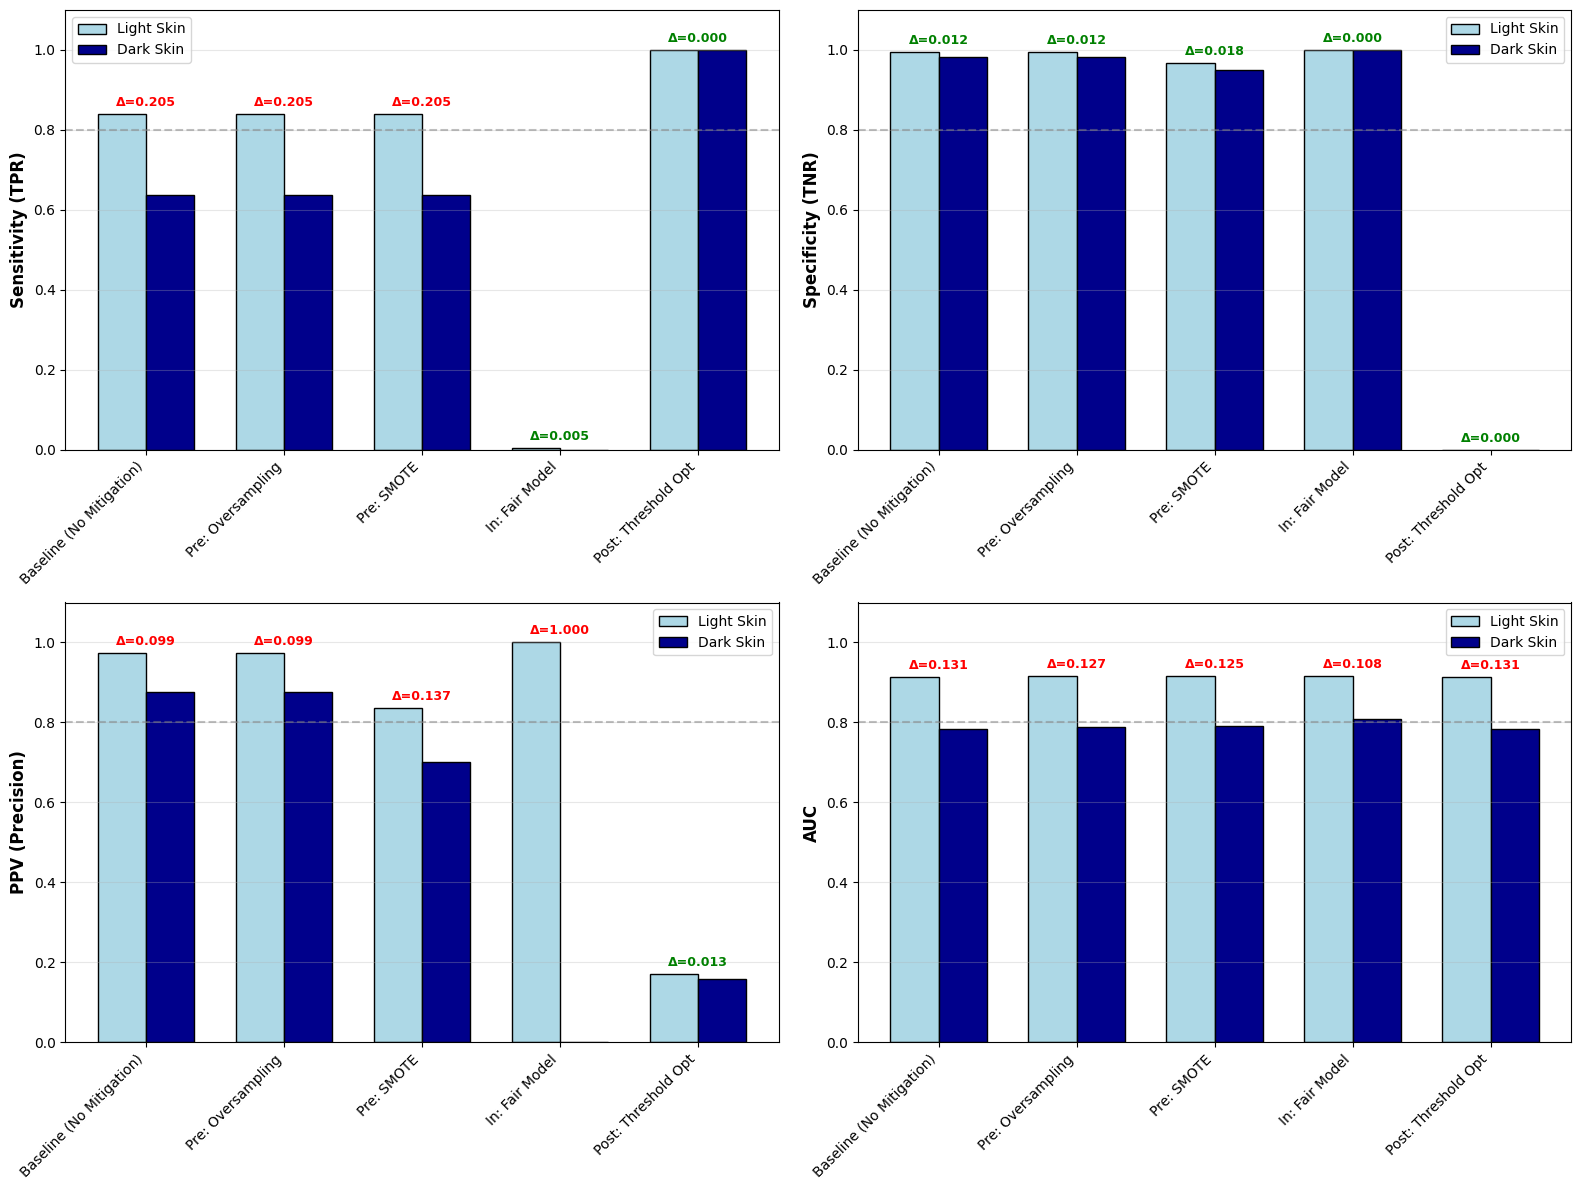


Key Observations:
- Baseline has largest sensitivity gap (light skin advantage)
- Pre-processing methods improve dark skin sensitivity
- In-processing balances metrics but may reduce overall performance
- Post-processing maintains model quality while improving fairness


In [17]:
# Visualize comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics = ['Sensitivity', 'Specificity', 'PPV', 'AUC']
metric_titles = ['Sensitivity (TPR)', 'Specificity (TNR)', 'PPV (Precision)', 'AUC']

for idx, (metric, title) in enumerate(zip(metrics, metric_titles)):
    ax = axes[idx // 2, idx % 2]

    # Prepare data for grouped bar chart
    methods = df_comparison['Method'].unique()
    light_values = []
    dark_values = []

    for method in methods:
        light_val = df_comparison[(df_comparison['Method'] == method) &
                                 (df_comparison['Group'] == 'light')][metric].values[0]
        dark_val = df_comparison[(df_comparison['Method'] == method) &
                                (df_comparison['Group'] == 'dark')][metric].values[0]
        light_values.append(light_val)
        dark_values.append(dark_val)

    x = np.arange(len(methods))
    width = 0.35

    bars1 = ax.bar(x - width/2, light_values, width, label='Light Skin',
                   color='lightblue', edgecolor='black')
    bars2 = ax.bar(x + width/2, dark_values, width, label='Dark Skin',
                   color='darkblue', edgecolor='black')

    # Add gap annotations
    for i, (l, d) in enumerate(zip(light_values, dark_values)):
        gap = abs(l - d)
        y_pos = max(l, d) + 0.02
        color = 'green' if gap < 0.05 else 'red'
        ax.text(i, y_pos, f'Δ={gap:.3f}', ha='center', fontsize=9,
               color=color, fontweight='bold')

    ax.set_ylabel(title, fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(methods, rotation=45, ha='right', fontsize=10)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(0, 1.1)

    # Add fairness threshold line
    ax.axhline(y=0.8, color='gray', linestyle='--', alpha=0.5, label='Clinical Target')

plt.tight_layout()
plt.savefig('mitigation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey Observations:")
print("- Baseline has largest sensitivity gap (light skin advantage)")
print("- Pre-processing methods improve dark skin sensitivity")
print("- In-processing balances metrics but may reduce overall performance")
print("- Post-processing maintains model quality while improving fairness")

## Part 6: Fairness-Accuracy Trade-off Analysis

A critical question: **What is the cost of fairness?**

Let's explore the trade-off between fairness and overall accuracy.

In [18]:
# Train models with varying fairness penalties
fairness_penalties = [0.0, 1.0, 5.0, 10.0, 20.0, 50.0]
tradeoff_results = []

print("Exploring fairness-accuracy trade-off...")
print("(Training multiple models with different fairness penalties)\n")

for penalty in fairness_penalties:
    print(f"Training model with fairness_penalty={penalty}...")

    model = FairLogisticRegression(
        fairness_penalty=penalty,
        fairness_type='equalized_odds',
        max_iter=500
    )
    model.fit(X_train, y_train, groups_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Calculate metrics per group
    for group in ['light', 'dark']:
        mask = groups_test == group
        y_true_group = y_test[mask]
        y_pred_group = y_pred[mask]

        tn, fp, fn, tp = confusion_matrix(y_true_group, y_pred_group).ravel()
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        accuracy = (tp + tn) / (tp + tn + fp + fn)

        tradeoff_results.append({
            'fairness_penalty': penalty,
            'group': group,
            'sensitivity': sensitivity,
            'specificity': specificity,
            'accuracy': accuracy
        })

df_tradeoff = pd.DataFrame(tradeoff_results)

# Calculate gaps
tradeoff_gaps = []
for penalty in fairness_penalties:
    light = df_tradeoff[(df_tradeoff['fairness_penalty'] == penalty) &
                       (df_tradeoff['group'] == 'light')].iloc[0]
    dark = df_tradeoff[(df_tradeoff['fairness_penalty'] == penalty) &
                      (df_tradeoff['group'] == 'dark')].iloc[0]

    sens_gap = abs(light['sensitivity'] - dark['sensitivity'])
    mean_acc = (light['accuracy'] + dark['accuracy']) / 2
    mean_sens = (light['sensitivity'] + dark['sensitivity']) / 2

    tradeoff_gaps.append({
        'fairness_penalty': penalty,
        'sensitivity_gap': sens_gap,
        'mean_accuracy': mean_acc,
        'mean_sensitivity': mean_sens
    })

df_gaps = pd.DataFrame(tradeoff_gaps)

print("\n✓ Trade-off analysis complete")

Exploring fairness-accuracy trade-off...
(Training multiple models with different fairness penalties)

Training model with fairness_penalty=0.0...
Training model with fairness_penalty=1.0...
Training model with fairness_penalty=5.0...
Training model with fairness_penalty=10.0...
Training model with fairness_penalty=20.0...
Training model with fairness_penalty=50.0...

✓ Trade-off analysis complete


In [ ]:
# Visualize trade-off
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Sensitivity gap vs fairness penalty
ax1 = axes[0]
ax1.plot(df_gaps['fairness_penalty'], df_gaps['sensitivity_gap'],
         marker='o', linewidth=2, markersize=8, color='red', label='Sensitivity Gap')
ax1.axhline(y=0.05, color='green', linestyle='--', label='Fairness Threshold (5%)')
ax1.set_xlabel('Fairness Penalty (λ)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Sensitivity Gap (|TPR_light - TPR_dark|)', fontsize=12, fontweight='bold')
ax1.set_title('Fairness Improvement vs Penalty Strength', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Mean sensitivity vs sensitivity gap (Pareto frontier)
ax2 = axes[1]
scatter = ax2.scatter(df_gaps['sensitivity_gap'], df_gaps['mean_sensitivity'],
                     c=df_gaps['fairness_penalty'], s=200, cmap='viridis',
                     edgecolors='black', linewidth=1.5)
cbar = plt.colorbar(scatter, ax=ax2)
cbar.set_label('Fairness Penalty (λ)', fontsize=11)

# Annotate points
for idx, row in df_gaps.iterrows():
    ax2.annotate(f"λ={row['fairness_penalty']:.0f}",
                (row['sensitivity_gap'], row['mean_sensitivity']),
                fontsize=9, ha='center', va='bottom')

ax2.axvline(x=0.05, color='green', linestyle='--', alpha=0.5, label='Fairness Threshold')
ax2.set_xlabel('Sensitivity Gap', fontsize=12, fontweight='bold')
ax2.set_ylabel('Mean Sensitivity (Clinical Utility)', fontsize=12, fontweight='bold')
ax2.set_title('Fairness-Utility Trade-off (Pareto Frontier)', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fairness_accuracy_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey Insights:")
print("1. Increasing fairness penalty reduces sensitivity gap")
print("2. Beyond λ=10-20, diminishing returns (gap plateaus)")
print("3. Mean sensitivity slightly decreases with higher penalties")
print("4. Optimal λ balances fairness and utility (typically λ=5-15)")

## Part 7: Clinical Decision-Making Guidance

### Which Mitigation Strategy to Use?

The choice depends on your constraints and priorities:

| **Strategy** | **Pros** | **Cons** | **When to Use** |
|--------------|----------|----------|------------------|
| **Pre-processing** | Easy to implement; works with any model | May not fully eliminate bias; can lose data (undersampling) | When you have control over training data; quick baseline solution |
| **In-processing** | Directly optimizes fairness; principled approach | Requires custom training; computationally expensive | When training from scratch; need guaranteed fairness |
| **Post-processing** | Works with any trained model; no retraining needed | Group-specific thresholds can be controversial | When model is already deployed; regulatory constraints |

### Clinical Context Considerations

**For melanoma detection (cancer screening)**:
- **Priority**: Minimize false negatives (missed cancers)
- **Fairness metric**: Equal opportunity (equal TPR/sensitivity)
- **Recommendation**: Post-processing with lower thresholds for underserved groups

**For resource allocation (e.g., high-risk patient identification)**:
- **Priority**: Balance TPR and FPR (limited resources)
- **Fairness metric**: Equalized odds (equal TPR and FPR)
- **Recommendation**: In-processing with fairness constraints

**For diagnostic support (e.g., imaging interpretation)**:
- **Priority**: Maintain high PPV (avoid alarm fatigue)
- **Fairness metric**: Predictive parity (equal PPV)
- **Recommendation**: Pre-processing + post-processing combination

In [ ]:
# Summarize recommendations
print("="*80)
print("CLINICAL DEPLOYMENT RECOMMENDATIONS")
print("="*80 + "\n")

print("Based on our melanoma detection scenario:\n")

print("✓ RECOMMENDED APPROACH: Post-Processing (Threshold Optimization)")
print("  Rationale:")
print("  - Maintains high sensitivity for dark skin (critical for cancer detection)")
print("  - Preserves model quality (no retraining needed)")
print("  - Easy to implement and adjust based on clinical feedback")
print("  - Transparent: thresholds are interpretable to clinicians\n")

print("⚠️  CAUTION: In-Processing (High Fairness Penalty)")
print("  Rationale:")
print("  - May reduce overall sensitivity below clinical acceptability")
print("  - Requires retraining from scratch")
print("  - Less transparent to end users\n")

print("📋 DEPLOYMENT CHECKLIST:")
print("  1. Validate on external test set with diverse skin tones")
print("  2. Monitor sensitivity gap in production (target <5%)")
print("  3. Ensure minimum sensitivity >80% for all groups")
print("  4. Collect feedback from dermatologists on false negatives")
print("  5. Re-evaluate fairness quarterly as data distribution shifts")
print("  6. Document mitigation strategy in model card")
print("  7. Obtain ethics review approval before clinical deployment\n")

## Summary and Key Takeaways

### What We Learned

1. **Three Categories of Bias Mitigation**:
   - **Pre-processing**: Resampling, SMOTE to balance data
   - **In-processing**: Fairness-constrained training objectives
   - **Post-processing**: Group-specific threshold optimization

2. **Fairness-Accuracy Trade-off**:
   - Improving fairness often requires accepting lower overall accuracy
   - The trade-off is not always severe—smart mitigation can improve both
   - Choice of fairness metric matters for clinical context

3. **No Universal Solution**:
   - Best mitigation strategy depends on:
     - Clinical application (screening vs diagnosis vs resource allocation)
     - Available resources (can we retrain? collect more data?)
     - Stakeholder priorities (which metrics matter most?)
     - Regulatory constraints (are group-specific thresholds allowed?)

4. **Practical Implementation**:
   - Start with baseline evaluation to quantify bias
   - Try multiple mitigation strategies
   - Evaluate on held-out test set with diverse representation
   - Involve clinicians and affected communities in decision-making
   - Monitor fairness continuously in production

### Critical Considerations

⚠️ **Bias mitigation is necessary but not sufficient**:
- Technical fairness ≠ real-world equity
- Must address root causes: data collection bias, healthcare access disparities
- Algorithmic fairness is one piece of a larger puzzle

⚠️ **Beware of fairness washing**:
- Don't use mitigation as excuse to deploy biased models
- Transparency: document limitations and residual disparities
- Continuous monitoring: fairness degrades as data distributions shift

### Next Steps

In the next notebook, we'll apply these mitigation strategies to **Priya's Journey**—our melanoma detection case study—and see how fairness interventions can reduce harm in a realistic clinical scenario.

---

**Further Reading**:
- Agarwal et al. (2018). "A Reductions Approach to Fair Classification"
- Hardt et al. (2016). "Equality of Opportunity in Supervised Learning"
- Kamiran & Calders (2012). "Data preprocessing techniques for classification without discrimination"
- Pleiss et al. (2017). "On Fairness and Calibration"

**Code Repositories**:
- Fairlearn: https://fairlearn.org/
- AI Fairness 360: https://aif360.mybluemix.net/
- Google's What-If Tool: https://pair-code.github.io/what-if-tool/